# Preprocessing
---

This notebook examines the dataset and converts the various spreadsheets into ones that will go directly into the models.

## Fetch Data

In [76]:
import pandas as pd
import numpy as np

atp_data_path = 'atp_match_data/'
start_year = 2020
csv = '.csv'

combined_data = []
for year in range(start_year, 2025):
    year_data = []
    for dtype in ['atp_matches_', 'atp_matches_futures_', 'atp_matches_qual_chall_']:
        df = pd.read_csv(atp_data_path + dtype + str(year) + csv)
        year_data.append(df)
    year_combined = pd.concat(year_data, keys=['matches', 'futures', 'qual_chall'])
    combined_data.append(year_combined)

combined = pd.concat(combined_data, keys=list(range(start_year, 2025)))
combined

tourney_id  tourney_name surface  draw_size  \
2020 matches    0      2020-8888       Atp Cup    Hard         24   
                1      2020-8888       Atp Cup    Hard         24   
                2      2020-8888       Atp Cup    Hard         24   
                3      2020-8888       Atp Cup    Hard         24   
                4      2020-8888       Atp Cup    Hard         24   
...                          ...           ...     ...        ...   
2024 qual_chall 11185  2024-8268  Yokkaichi CH    Hard         32   
                11186  2024-8268  Yokkaichi CH    Hard         32   
                11187  2024-8268  Yokkaichi CH    Hard         32   
                11188  2024-8268  Yokkaichi CH    Hard         32   
                11189  2024-8268  Yokkaichi CH    Hard         32   

                      tourney_level  tourney_date  match_num  winner_id  \
2020 matches    0                 A      20200106        300     104925   
                1                 A      20200106        299     105138   
                2                 A      20200106        298     104925   
                3                 A      20200106        297     105583   
                4                 A      20200106        296     104745   
...                             ...           ...        ...        ...   
2024 qual_chall 11185             C      20241125        342     122352   
                11186             C      20241125        341     207987   
                11187             C      20241125        340     209951   
                11188             C      20241125        338     202113   
                11189             C      20241125        337     211774   

                       winner_seed winner_entry  ... l_1stIn l_1stWon  \
2020 matches    0              NaN          NaN  ...    51.0     39.0   
                1              NaN          NaN  ...    35.0     21.0   
                2              NaN          NaN  ...    57.0     35.0   
                3              NaN          NaN  ...    54.0     39.0   
                4              NaN          NaN  ...    55.0     37.0   
...                            ...          ...  ...     ...      ...   
2024 qual_chall 11185          4.0          NaN  ...    54.0     29.0   
                11186          9.0          NaN  ...    31.0     16.0   
                11187          5.0          NaN  ...    41.0     22.0   
                11188          6.0          NaN  ...    68.0     41.0   
                11189         11.0          NaN  ...    26.0     11.0   

                       l_2ndWon l_SvGms  l_bpSaved  l_bpFaced  winner_rank  \
2020 matches    0           6.0    10.0        6.0        8.0          2.0   
                1           6.0     9.0        5.0       10.0         10.0   
                2          25.0    14.0        6.0       11.0          2.0   
                3          14.0    12.0        0.0        1.0         34.0   
                4          10.0    14.0        1.0        5.0          1.0   
...                         ...     ...        ...        ...          ...   
2024 qual_chall 11185       9.0    10.0        5.0        9.0        409.0   
                11186      10.0     8.0        4.0        8.0        507.0   
                11187       8.0    10.0        4.0       10.0        429.0   
                11188      23.0    16.0        7.0       12.0        528.0   
                11189       7.0     7.0        4.0        8.0        545.0   

                      winner_rank_points loser_rank loser_rank_points  
2020 matches    0                 9055.0        1.0            9985.0  
                1                 2335.0       34.0            1251.0  
                2                 9055.0        5.0            5705.0  
                3                 1251.0       17.0            1840.0  
                4                 9985.0       18.0            1775.0  
...                                  ...      

## Fix Data

In [77]:
# Score conversions
valid_chars = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '-', '(', ')', ' ']
combined['invalid'] = combined['score'].apply(
    lambda x: (not all(c in valid_chars for c in x)) if isinstance(x, str) else False
)
combined = combined[~combined['invalid']] # Remove invalid scores
combined.drop(columns=['invalid'], inplace=True)

In [78]:
combined['score'].info()

<class 'pandas.Series'>
MultiIndex: 119422 entries, (np.int64(2020), 'matches', np.int64(0)) to (np.int64(2024), 'qual_chall', np.int64(11189))
Series name: score
Non-Null Count   Dtype
--------------   -----
119412 non-null  str  
dtypes: str(1)
memory usage: 2.0+ MB


In [79]:
combined['score'] = combined['score'].apply(lambda x: x.split(' ') if isinstance(x, str) else np.nan)
combined['sets_played'] = combined['score'].apply(lambda x: len(x) if isinstance(x, list) else np.nan)

In [80]:
def score_breakdown(scores):
    if not isinstance(scores, list):
        return np.nan, np.nan, np.nan, np.nan
    
    w_sets, l_sets = 0, 0
    w_tiebreak, l_tiebreak = 0, 0
    
    for score in scores:
        set_score = score.split('(')[0]
        if '(' in score:  # Tiebreak set
            _, tiebreak_score = score.split('(')
            tiebreak_score = tiebreak_score.rstrip(')')
            l_tiebreak += int(tiebreak_score)
            w_tiebreak += max(7, l_tiebreak + 2)  # Winner needs at least 7 points and 2 more than loser
        
        w, l = [int(x) for x in set_score.split('-')]
        w_sets += w
        l_sets += l
    
    return w_sets, l_sets, w_tiebreak, l_tiebreak

In [81]:
combined[['w_sets', 'l_sets', 'w_tiebreak', 'l_tiebreak']] = combined["score"].apply(score_breakdown).tolist()

In [82]:
combined.drop(columns=['score'], inplace=True)

### NaN Values

In [83]:
# To remove these columns from the combined dataframe, not beneficial for analysis
# Some columns are kept for result interpretation
# Keeping tourney_id for game_id purposes
remove_cols = [     # Not relevent to winner/loser analysis
    'tourney_name',
    'tourney_date',
    'match_num',
    'winner_seed',  # Player information already in data, name irrelevant, id for future analysis
    'winner_name',
    'winner_ioc',   # Country info
    'loser_seed',
    'loser_name',
    'loser_ioc',
    'round',       # Likely low correlation with winner/loser
    'draw_size',   # Irrelevant to winner/loser analysis
]

combined.drop(columns=remove_cols, inplace=True)

In [84]:
combined.isna().sum() # Check NaN counts to drop rows

tourney_id                0
surface                  50
tourney_level             0
winner_id                 0
winner_entry          95625
winner_hand               0
winner_ht             11593
winner_age              340
loser_id                  0
loser_entry           76158
loser_hand                0
loser_ht              23092
loser_age              1785
best_of                   0
minutes               67843
w_ace                 66192
w_df                  66192
w_svpt                66192
w_1stIn               66192
w_1stWon              66192
w_2ndWon              66192
w_SvGms               66195
w_bpSaved             66192
w_bpFaced             66192
l_ace                 66192
l_df                  66192
l_svpt                66192
l_1stIn               66192
l_1stWon              66192
l_2ndWon              66192
l_SvGms               66195
l_bpSaved             66192
l_bpFaced             66192
winner_rank            4043
winner_rank_points     4043
loser_rank          

In [85]:
# Large NaN counts, not beneficial for analysis
# Minutes and in-game columns will be shifted to different dataframe for future analysis
drop_cols = [
    'winner_entry',
    'loser_entry',
    'winner_rank',
    'loser_rank'
]

shifted_cols = [
    'minutes',
    'winner_id',
    'w_ace',
    'w_df',
    'w_svpt',
    'w_1stIn',
    'w_1stWon',
    'w_2ndWon',
    'w_SvGms',
    'w_bpSaved',
    'w_bpFaced',
    'w_sets',
    'w_tiebreak',
    'loser_id',
    'l_ace',
    'l_df',
    'l_svpt',
    'l_1stIn',
    'l_1stWon',
    'l_2ndWon',
    'l_SvGms',
    'l_bpSaved',
    'l_bpFaced',
    'l_sets',
    'l_tiebreak'
]

shifted = combined[shifted_cols].copy()
shifted['tourney_id'] = combined['tourney_id']
combined.drop(columns=drop_cols + shifted_cols, inplace=True)

In [86]:
combined.dropna(inplace=True)

In [87]:
combined.describe()

,winner_ht,winner_age,loser_ht,loser_age,best_of,winner_rank_points,loser_rank_points,sets_played
count,85873.000000,85873.000000,85873.000000,85873.000000,85873.000000,85873.000000,85873.000000,85873.000000
mean,184.704121,25.136889,184.213245,25.192402,3.055873,432.816636,294.330197,2.378361
std,9.609180,4.199781,10.440270,4.300127,0.329584,1033.288765,642.426627,0.539195
min,3.000000,15.300000,3.000000,15.000000,3.000000,1.000000,1.000000,1.000000
25%,180.000000,22.000000,180.000000,22.000000,3.000000,52.000000,28.000000,2.000000
50%,185.000000,24.600000,185.000000,24.700000,3.000000,136.000000,102.000000,2.000000
75%,189.000000,27.700000,188.000000,27.800000,3.000000,386.000000,303.000000,3.000000
max,211.000000,45.300000,211.000000,46.300000,5.000000,12113.000000,12113.000000,5.000000


In [88]:
combined.info() # Checking column datatypes

<class 'pandas.DataFrame'>
MultiIndex: 85873 entries, (np.int64(2020), 'matches', np.int64(0)) to (np.int64(2024), 'qual_chall', np.int64(11188))
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          85873 non-null  str    
 1   surface             85873 non-null  str    
 2   tourney_level       85873 non-null  object 
 3   winner_hand         85873 non-null  str    
 4   winner_ht           85873 non-null  float64
 5   winner_age          85873 non-null  float64
 6   loser_hand          85873 non-null  str    
 7   loser_ht            85873 non-null  float64
 8   loser_age           85873 non-null  float64
 9   best_of             85873 non-null  int64  
 10  winner_rank_points  85873 non-null  float64
 11  loser_rank_points   85873 non-null  float64
 12  sets_played         85873 non-null  float64
dtypes: float64(7), int64(1), object(1), str(4)
memory usage: 9.5+ MB


In [89]:
shifted.info()

<class 'pandas.DataFrame'>
MultiIndex: 119422 entries, (np.int64(2020), 'matches', np.int64(0)) to (np.int64(2024), 'qual_chall', np.int64(11189))
Data columns (total 26 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   minutes     51579 non-null   float64
 1   winner_id   119422 non-null  int64  
 2   w_ace       53230 non-null   float64
 3   w_df        53230 non-null   float64
 4   w_svpt      53230 non-null   float64
 5   w_1stIn     53230 non-null   float64
 6   w_1stWon    53230 non-null   float64
 7   w_2ndWon    53230 non-null   float64
 8   w_SvGms     53227 non-null   float64
 9   w_bpSaved   53230 non-null   float64
 10  w_bpFaced   53230 non-null   float64
 11  w_sets      119412 non-null  float64
 12  w_tiebreak  119412 non-null  float64
 13  loser_id    119422 non-null  int64  
 14  l_ace       53230 non-null   float64
 15  l_df        53230 non-null   float64
 16  l_svpt      53230 non-null   float64
 17  l_1stIn     53230

### One Hot Encoding

In [90]:
# column -> datatype
# -----------------------------
# winner_hand and loser_hand -> int (R -> 1, L -> 2, U -> NaN)

whand_dummies = pd.get_dummies(combined['winner_hand'])
lhand_dummies = pd.get_dummies(combined['loser_hand'])


In [91]:
whand_dummies

A      L      R      U
2020 matches    0      False  False   True  False
                1      False  False   True  False
                2      False  False   True  False
                3      False  False   True  False
                4      False   True  False  False
...                      ...    ...    ...    ...
2024 qual_chall 11184  False  False   True  False
                11185  False  False   True  False
                11186  False  False   True  False
                11187  False   True  False  False
                11188  False  False   True  False

[85873 rows x 4 columns]

In [92]:
whand_dummies.drop(columns=['U'], inplace=True) # Drop unknown hand column
whand_dummies.rename(columns={'R': 'w_right', 'L': 'w_left', 'A': 'w_ambidextrous'}, inplace=True)

In [93]:
whand_dummies

w_ambidextrous  w_left  w_right
2020 matches    0               False   False     True
                1               False   False     True
                2               False   False     True
                3               False   False     True
                4               False    True    False
...                               ...     ...      ...
2024 qual_chall 11184           False   False     True
                11185           False   False     True
                11186           False   False     True
                11187           False    True    False
                11188           False   False     True

[85873 rows x 3 columns]

In [94]:
lhand_dummies

A      L      R      U
2020 matches    0      False   True  False  False
                1      False  False   True  False
                2      False  False   True  False
                3      False  False   True  False
                4      False  False   True  False
...                      ...    ...    ...    ...
2024 qual_chall 11184  False  False   True  False
                11185  False  False   True  False
                11186  False  False   True  False
                11187  False  False   True  False
                11188  False  False   True  False

[85873 rows x 4 columns]

In [95]:
lhand_dummies.drop(columns=['U'], inplace=True) # Drop unknown hand column
lhand_dummies.rename(columns={'R': 'l_right', 'L': 'l_left', 'A': 'l_ambidextrous'}, inplace=True)

In [96]:
lhand_dummies

l_ambidextrous  l_left  l_right
2020 matches    0               False    True    False
                1               False   False     True
                2               False   False     True
                3               False   False     True
                4               False   False     True
...                               ...     ...      ...
2024 qual_chall 11184           False   False     True
                11185           False   False     True
                11186           False   False     True
                11187           False   False     True
                11188           False   False     True

[85873 rows x 3 columns]

In [97]:
# Replacing with one-hot encoding
combined.drop(columns=['winner_hand', 'loser_hand'], inplace=True)
combined = pd.concat([combined, whand_dummies, lhand_dummies], axis=1)
combined.info()

<class 'pandas.DataFrame'>
MultiIndex: 85873 entries, (np.int64(2020), 'matches', np.int64(0)) to (np.int64(2024), 'qual_chall', np.int64(11188))
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          85873 non-null  str    
 1   surface             85873 non-null  str    
 2   tourney_level       85873 non-null  object 
 3   winner_ht           85873 non-null  float64
 4   winner_age          85873 non-null  float64
 5   loser_ht            85873 non-null  float64
 6   loser_age           85873 non-null  float64
 7   best_of             85873 non-null  int64  
 8   winner_rank_points  85873 non-null  float64
 9   loser_rank_points   85873 non-null  float64
 10  sets_played         85873 non-null  float64
 11  w_ambidextrous      85873 non-null  bool   
 12  w_left              85873 non-null  bool   
 13  w_right             85873 non-null  bool   
 14  l_ambidextrous      85873 non-nu

In [98]:
combined

tourney_id surface tourney_level  winner_ht  winner_age  \
2020 matches    0      2020-8888    Hard             A      188.0        32.6   
                1      2020-8888    Hard             A      183.0        31.7   
                2      2020-8888    Hard             A      188.0        32.6   
                3      2020-8888    Hard             A      183.0        29.5   
                4      2020-8888    Hard             A      185.0        33.5   
...                          ...     ...           ...        ...         ...   
2024 qual_chall 11184  2024-8268    Hard             C      175.0        26.1   
                11185  2024-8268    Hard             C      193.0        30.6   
                11186  2024-8268    Hard             C      157.0        24.9   
                11187  2024-8268    Hard             C      196.0        22.7   
                11188  2024-8268    Hard             C      168.0        24.5   

                       loser_ht  loser_age  best_of  winner_rank_points  \
2020 matches    0         185.0       33.5        3              9055.0   
                1         183.0       29.5        3              2335.0   
                2         198.0       23.9        3              9055.0   
                3         198.0       23.6        3              1251.0   
                4         183.0       20.8        3              9985.0   
...                         ...        ...      ...                 ...   
2024 qual_chall 11184     188.0       29.7        3                82.0   
                11185     175.0       25.6        3               113.0   
                11186     175.0       26.8        3                76.0   
                11187     173.0       25.0        3               100.0   
                11188     180.0       19.8        3                71.0   

                       loser_rank_points  sets_played  w_ambidextrous  w_left  \
2020 matches    0                 9985.0          2.0           False   False   
                1                 1251.0          2.0           False   False   
                2                 5705.0          3.0           False   False   
                3                 1840.0          2.0           False   False   
                4                 1775.0          3.0           False    True   
...                                  ...          ...             ...     ...   
2024 qual_chall 11184               37.0          2.0           False   False   
                11185               11.0          2.0           False   False   
                11186               22.0          2.0           False   False   
                11187               40.0          2.0           False    True   
                11188               20.0          3.0           False   False   

                       w_right  l_ambidextrous  l_left  l_right  
2020 matches    0         True           False    True    False  
                1         True           False   False     True  
                2         True           False   False     True  
                3         True           False   False     True  
                4        False           False   False     True  
...                        ...             ...     ...      ...  
2024 qual_chall 11184     True           False   False     True  
                11185     True           False   False     True  
                11186     True           False   False     True  
                11187    False           False   False     True  
                11188     True           False   False     True  

[85873 rows x 17 columns]

### Type Casting

In [99]:
# winner_/loser_age -> single decimal float
# all other numbers small size integers
import numpy as np

combined = combined.astype(
    dtype={
        'winner_age': np.float32,
        'loser_age': np.float32,
        'winner_ht': np.int16,
        'loser_ht': np.int16,
        'best_of': np.int8,
        'winner_rank_points': np.int32,
        'loser_rank_points': np.int32
    }
)

In [100]:
combined.info()

<class 'pandas.DataFrame'>
MultiIndex: 85873 entries, (np.int64(2020), 'matches', np.int64(0)) to (np.int64(2024), 'qual_chall', np.int64(11188))
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          85873 non-null  str    
 1   surface             85873 non-null  str    
 2   tourney_level       85873 non-null  object 
 3   winner_ht           85873 non-null  int16  
 4   winner_age          85873 non-null  float32
 5   loser_ht            85873 non-null  int16  
 6   loser_age           85873 non-null  float32
 7   best_of             85873 non-null  int8   
 8   winner_rank_points  85873 non-null  int32  
 9   loser_rank_points   85873 non-null  int32  
 10  sets_played         85873 non-null  float64
 11  w_ambidextrous      85873 non-null  bool   
 12  w_left              85873 non-null  bool   
 13  w_right             85873 non-null  bool   
 14  l_ambidextrous      85873 non-nu

### Feature Tweaking

In [101]:
# slam > finals > davis > masters > tour > challenger > itf25k > itf15k in terms of importance, so we can assign values accordingly, no satellite tournaments in data
combined = combined[combined['tourney_level'] != 'O'] # Drop unknown tourney level rows

pressure_mapping = {
    'G': 8, # Grand Slam
    'F': 7, # Finals
    'D': 6, # Davis Cup
    'M': 5, # Masters 1000
    'A': 4, # ATP Tour
    'C': 3, # Challenger
    25: 2,  # ITF 25K
    15: 1,  # ITF 15K
    'S': 0, # Satellite (not in data)
}

combined['pressure'] = combined['tourney_level'].map(pressure_mapping).astype(np.int16)
combined.drop(columns=['tourney_level'], inplace=True)
combined['pressure']

2020  matches     0        4
                  1        4
                  2        4
                  3        4
                  4        4
                          ..
2024  qual_chall  11184    3
                  11185    3
                  11186    3
                  11187    3
                  11188    3
Name: pressure, Length: 85813, dtype: int16

In [102]:
# court type determines ball speed, bounce, and friction
# all three are correlated but have different effects, so each column will be preserved
# kind of feature crossing but also kind of encoding

court_mapping = {   # speed, bounce, friction
    'Hard': (2, 2, 2),
    'Clay': (1, 3, 3),
    'Grass': (3, 1, 1),
    'Carpet': (4, 0, 0)  # Carpet is very fast with low bounce and friction, but is not used in professional tennis anymore, so it will be treated as an outlier
}

combined[['court_speed', 'court_bounce', 'court_friction']] = combined['surface'].map(court_mapping).to_list()
combined.drop(columns=['surface'], inplace=True)

In [103]:
# while handedness can independently affect results, it can also affect match dynamic
combined['asymmetry'] = (combined['w_right'] * combined['l_left'] + combined['w_left'] * combined['l_right'])

In [104]:
combined['age_diff'] = combined['loser_age'] - combined['winner_age']
combined['height_diff'] = combined['winner_ht'] - combined['loser_ht']
combined['rank_points_diff'] = combined['winner_rank_points'] - combined['loser_rank_points']
shifted['set_diff'] = shifted['w_sets'] - shifted['l_sets']

## Statistics

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

In [106]:
combined.columns, shifted.columns

(Index(['tourney_id', 'winner_ht', 'winner_age', 'loser_ht', 'loser_age',
        'best_of', 'winner_rank_points', 'loser_rank_points', 'sets_played',
        'w_ambidextrous', 'w_left', 'w_right', 'l_ambidextrous', 'l_left',
        'l_right', 'pressure', 'court_speed', 'court_bounce', 'court_friction',
        'asymmetry', 'age_diff', 'height_diff', 'rank_points_diff'],
       dtype='str'),
 Index(['minutes', 'winner_id', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn',
        'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'w_sets',
        'w_tiebreak', 'loser_id', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn',
        'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced', 'l_sets',
        'l_tiebreak', 'tourney_id', 'set_diff'],
       dtype='str'))

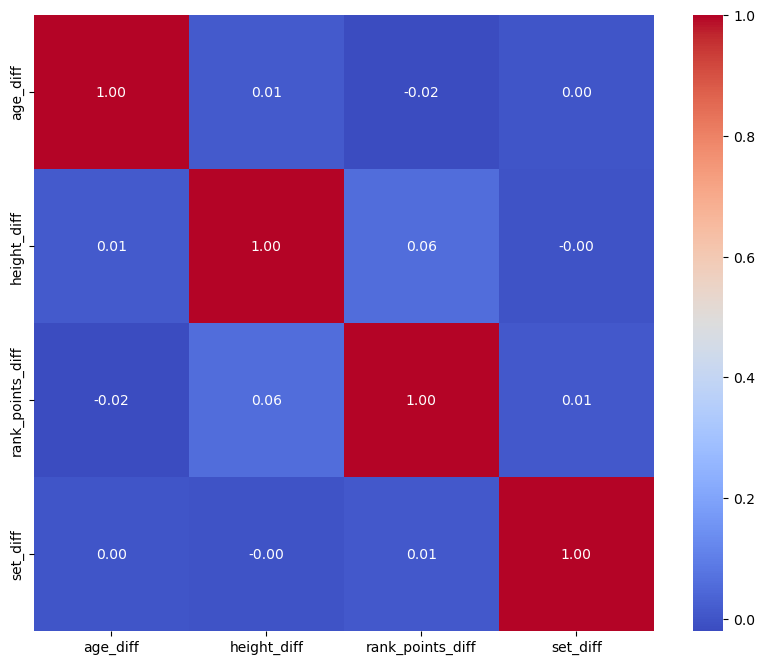

In [107]:
# checking correlation of various features with winner/loser values
merged = combined[['tourney_id', 'age_diff', 'height_diff', 'rank_points_diff']].merge(
    shifted[['tourney_id', 'set_diff']],
    on="tourney_id"
)
corr = merged.drop('tourney_id', axis=1).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

5.144139796474849


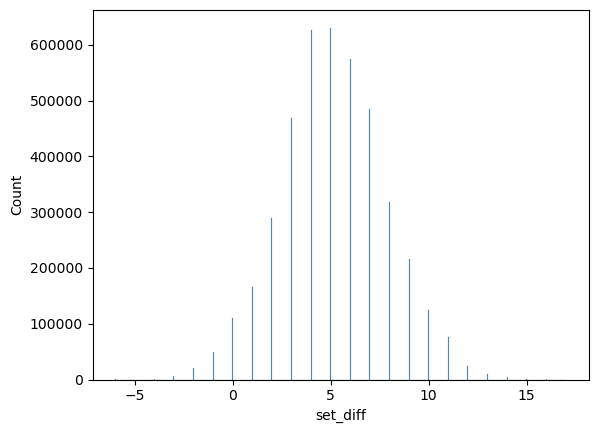

0.16388012


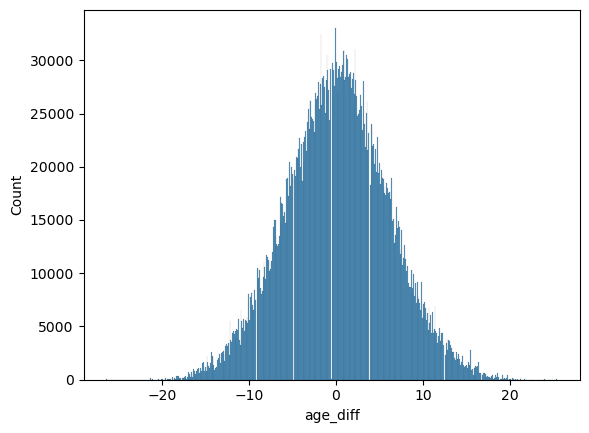

0.6034684850972853


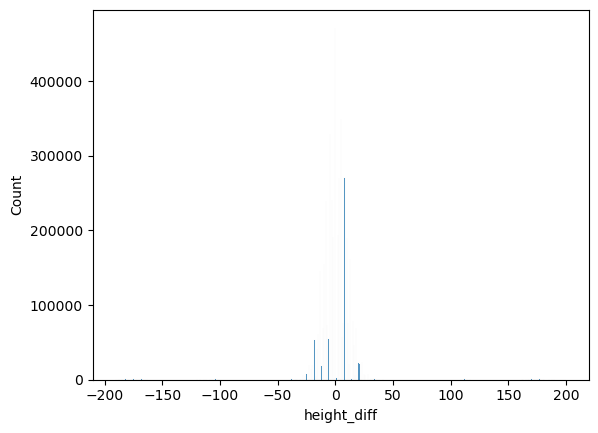

281.38268505349964


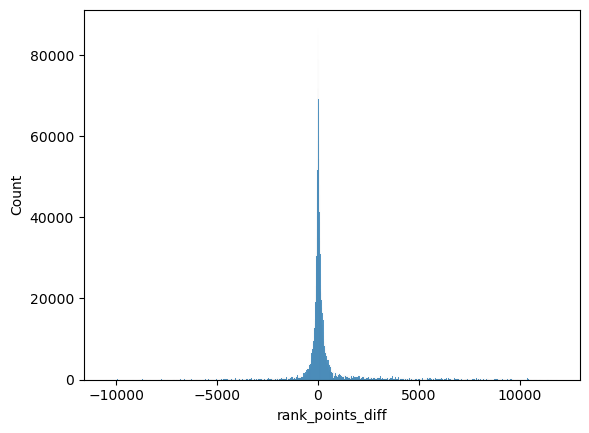

In [108]:
# very low correlation was found, checking distributions of features
sns.histplot(data=merged, x="set_diff")
print(merged['set_diff'].mean())
plt.show()

sns.histplot(data=merged, x="age_diff")
print(merged['age_diff'].mean())
plt.show()

sns.histplot(data=merged, x="height_diff")
print(merged['height_diff'].mean())
plt.show()

sns.histplot(data=merged, x="rank_points_diff")
print(merged['rank_points_diff'].mean())
plt.show()

### Prep for Model Training and Preds

In [109]:
# To shuffle winner and loser columns into player 1 and player 2 with third column indicating winner
# Split combined into two with 50% of rows each, then swap winner and loser columns in one and concatenate back together, shuffle rows, and reset index
combined = combined.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle rows before splitting to ensure randomness
half = len(combined) // 2
combined_1 = combined.iloc[:half].copy()
combined_2 = combined.iloc[half:].copy()

combined_1.rename(
    lambda x: x.replace('winner', '1')
               .replace('loser', '2')
               .replace('w_', '1_')
               .replace('l_', '2_'),
    axis="columns",
    inplace=True
)

combined_2.rename(
    lambda x: x.replace('winner', '2')
               .replace('loser', '1')
               .replace('w_', '2_')
               .replace('l_', '1_'),
    axis="columns",
    inplace=True
)

combined_1['winner_1'] = 1
combined_2['winner_1'] = 0

combined_final = pd.concat([combined_1, combined_2], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

In [110]:
combined_1.info(), combined_2.info(), combined_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 42906 entries, 0 to 42905
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tourney_id        42906 non-null  str    
 1   1_ht              42906 non-null  int16  
 2   1_age             42906 non-null  float32
 3   2_ht              42906 non-null  int16  
 4   2_age             42906 non-null  float32
 5   best_of           42906 non-null  int8   
 6   1_rank_points     42906 non-null  int32  
 7   2_rank_points     42906 non-null  int32  
 8   sets_played       42906 non-null  float64
 9   1_ambidextrous    42906 non-null  bool   
 10  1_left            42906 non-null  bool   
 11  1_right           42906 non-null  bool   
 12  2_ambidextrous    42906 non-null  bool   
 13  2_left            42906 non-null  bool   
 14  2_right           42906 non-null  bool   
 15  pressure          42906 non-null  int16  
 16  court_speed       42906 non-null  int64  
 17  cour

(None, None, None)

In [111]:
combined_final

,tourney_id,1_ht,1_age,2_ht,2_age,best_of,1_rank_points,2_rank_points,sets_played,1_ambidextrous,...,2_right,pressure,court_speed,court_bounce,court_friction,asymmetry,age_diff,height_diff,rank_points_diff,winner_1
0,2023-M-ITF-CYP-05A-2023,185,27.600000,180,25.900000,3,4,32,3.0,False,...,True,1,2,2,2,False,1.700001,-5,28,0
1,2022-580,185,25.700001,178,26.500000,3,401,385,3.0,False,...,True,8,2,2,2,False,0.799999,7,16,1
2,2023-M-ITF-TUN-11A-2023,175,24.100000,178,19.900000,3,159,100,3.0,False,...,True,2,2,2,2,False,4.200001,3,-59,0
3,2023-560,185,33.200001,183,21.700001,3,254,442,2.0,False,...,False,8,2,2,2,False,11.500000,-2,188,0
4,2020-7077,185,26.900000,188,24.100000,3,269,296,2.0,False,...,True,3,1,3,3,False,-2.799999,-3,-27,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85808,2022-M-ITF-DOM-08A-2022,183,18.700001,193,29.200001,3,31,46,2.0,False,...,True,1,2,2,2,False,10.500000,-10,-15,1
85809,2023-M-ITF-TUR-02A-2023,180,28.200001,185,23.900000,3,64,106,2.0,False,...,True,1,1,3,3,True,4.300001,5,42,0
85810,2024-560,183,28.200001,185,32.400002,3,459,273,3.0,False,...,True,8,2,2,2,False,-4.200001,2,-186,0
85811,2023-M-ITF-GER-02A-2023,188,19.500000,193,18.299999,3,102,3,2.0,False,...,True,1,2,2,2,False,-1.200001,-5,99,1


## Export Data

In [112]:
# Exporting the processed dataframes to csv files for use in the next steps of the project
import os

os.makedirs('processed_data', exist_ok=True)
combined.to_csv('processed_data/combined.csv')
combined_final.to_csv('processed_data/train_test.csv')
shifted.to_csv('processed_data/relevant_stats.csv')